# K-Nearest Neighbors Regression

In [1]:
from pathlib import Path
import sys

import pandas as pd

from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import engineer_features
from src.encoding import encode_features
from src.split_data import split_data
from src.evaluation import evaluate_model

## Load Dataset

In [4]:
df = load_data()

df = clean_data(df)

df = engineer_features(df)

df = encode_features(df)

X_train, X_test, y_train, y_test = split_data(df)

In [5]:
print(X_train.shape)
print(X_test.shape)

(1020, 71)
(255, 71)


## Feature Scaling

In [6]:
scaler = StandardScaler()

In [7]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [8]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(1020, 71)
(255, 71)


## Train KNN Regressor

In [9]:
knn = KNeighborsRegressor(
    n_neighbors=5
)

In [10]:
knn.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [11]:
y_pred = knn.predict(
    X_test_scaled
)

In [12]:
comparison = pd.DataFrame(
    {
        "Actual Price": y_test,
        "Predicted Price": y_pred,
    }
)

comparison.head(10)

,Actual Price,Predicted Price
1179,650.00,653.324
342,716.00,783.800
649,1584.00,1821.798
772,1020.00,921.000
803,1749.00,1920.284
358,557.37,719.602
44,999.00,1215.300
231,330.00,381.780
618,2267.86,1738.000
43,682.00,792.600


## Evaluate Model

In [13]:
metrics = evaluate_model(
    y_test,
    y_pred
)

metrics

{'MAE': 226.49201568627453,
 'RMSE': 353.63651456714706,
 'R2': 0.7480377016446934}

In [14]:
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

MAE: 226.4920
RMSE: 353.6365
R2: 0.7480


In [15]:
train_score = knn.score(
    X_train_scaled,
    y_train
)

test_score = knn.score(
    X_test_scaled,
    y_test
)

print(f"Train : {train_score:.4f}")
print(f"Test  : {test_score:.4f}")

Train : 0.8124
Test  : 0.7480


## Finding the Best K

In [16]:
from sklearn.metrics import r2_score

In [17]:
k_values = []

scores = []

In [18]:
for k in range(1, 31):

    model = KNeighborsRegressor(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train,
    )

    prediction = model.predict(
        X_test_scaled
    )

    score = r2_score(
        y_test,
        prediction,
    )

    k_values.append(k)

    scores.append(score)

In [19]:
results = pd.DataFrame(
    {
        "K": k_values,
        "R2": scores,
    }
)

results.head()

,K,R2
0,1,0.749088
1,2,0.782250
2,3,0.777851
3,4,0.773520
4,5,0.748038


In [20]:
best_row = results.loc[
    results["R2"].idxmax()
]

best_row

K     2.00000
R2    0.78225
Name: 1, dtype: float64

In [21]:
print(f"Best K : {best_row['K']}")

print(f"Best R² : {best_row['R2']:.4f}")

Best K : 2.0
Best R² : 0.7822


In [22]:
import matplotlib.pyplot as plt

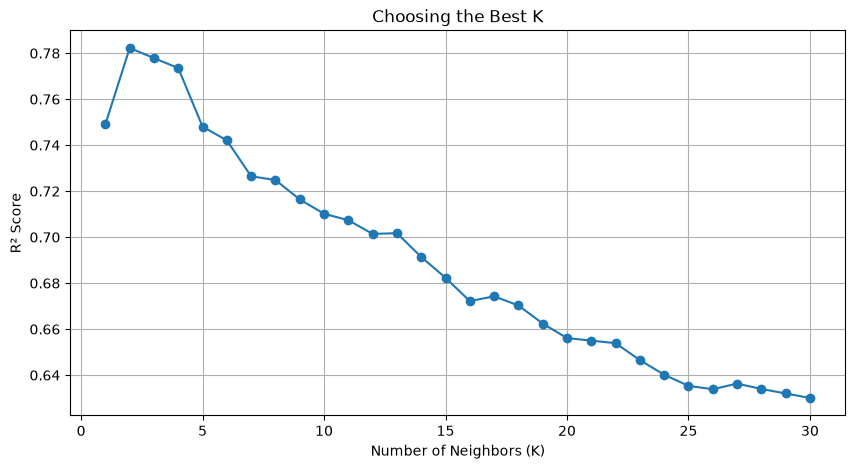

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    k_values,
    scores,
    marker="o",
)

plt.title("Choosing the Best K")

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("R² Score")

plt.grid(True)

plt.show()

## Train Final KNN Model

In [24]:
best_k = int(best_row["K"])

best_k

2

In [25]:
knn_final = KNeighborsRegressor(
    n_neighbors=best_k
)

In [26]:
knn_final.fit(
    X_train_scaled,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [27]:
y_pred = knn_final.predict(
    X_test_scaled
)

In [28]:
comparison = pd.DataFrame(
    {
        "Actual Price": y_test,
        "Predicted Price": y_pred,
    }
)

comparison.head(10)

,Actual Price,Predicted Price
1179,650.00,686.815
342,716.00,979.000
649,1584.00,1569.495
772,1020.00,916.500
803,1749.00,2212.210
358,557.37,624.005
44,999.00,1355.750
231,330.00,348.000
618,2267.86,1556.500
43,682.00,827.000


In [29]:
metrics = evaluate_model(
    y_test,
    y_pred
)

metrics

{'MAE': 221.66372549019607, 'RMSE': 328.7523009680156, 'R2': 0.782249600453798}

In [30]:
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

MAE: 221.6637
RMSE: 328.7523
R2: 0.7822


In [31]:
train_score = knn_final.score(
    X_train_scaled,
    y_train
)

test_score = knn_final.score(
    X_test_scaled,
    y_test
)

print(f"Train : {train_score:.4f}")

print(f"Test  : {test_score:.4f}")

Train : 0.9114
Test  : 0.7822


# Conclusion

KNN Regression was trained using scaled features.

The optimal value of K was selected by testing values from 1 to 30.

Best K = 2

Although KNN improved after tuning, it still performed worse than Random Forest.

Therefore, Random Forest remains the best-performing model for this dataset.